In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
import pandas as pd
data = pd.read_csv('/content/gdrive/My Drive/oc/oc_features_399_Svr.csv')
data

,Unnamed: 0,svr_input,svr_values
0,0,"[4.553357751368833, 3.459271947744673, 4.34289...",[0.5404]
1,1,"[4.02201416875017, 4.963312873460166, 3.336249...",[0.56061]
2,2,"[3.0027762095291055, 3.0297486353121004, 2.674...",[0.33838]
3,3,"[5.9999702201514165, 5.998465392146576, 5.1046...",[0.88384]
4,4,"[7.836202523608943, 5.555585430116952, 5.55439...",[0.89394]
...,...,...,...
25936,25936,"[2.0881372587647924, 1.6002927751532627, 1.380...",[0.40404]
25937,25937,"[5.283746476146319, 4.658630608644812, 3.33744...",[0.62626]
25938,25938,"[2.3827924289958844, 2.996228691439175, 1.4063...",[0.25253000000000003]
25939,25939,"[1.8856034579726, 2.3909268333279265, 2.299859...",[0.20706999999999998]


In [6]:
# lat =[]
# lon =[]
# print(data['predicted'][0])
# for i in range(len(data)):
#   if(data['predicted'][i] < 0):
#     print(data[i][1])
#     lat.append(data[i][1])
#     # lon.append(data[i][2])
# print(len(lat) , len(lon))


KeyError: ignored

In [7]:
data=data.drop(['Unnamed: 0'], axis = 1) 

In [8]:
print(data.head())

                                           svr_input svr_values
0  [4.553357751368833, 3.459271947744673, 4.34289...   [0.5404]
1  [4.02201416875017, 4.963312873460166, 3.336249...  [0.56061]
2  [3.0027762095291055, 3.0297486353121004, 2.674...  [0.33838]
3  [5.9999702201514165, 5.998465392146576, 5.1046...  [0.88384]
4  [7.836202523608943, 5.555585430116952, 5.55439...  [0.89394]


In [9]:
print(data['svr_input'])

0        [4.553357751368833, 3.459271947744673, 4.34289...
1        [4.02201416875017, 4.963312873460166, 3.336249...
2        [3.0027762095291055, 3.0297486353121004, 2.674...
3        [5.9999702201514165, 5.998465392146576, 5.1046...
4        [7.836202523608943, 5.555585430116952, 5.55439...
                               ...                        
25936    [2.0881372587647924, 1.6002927751532627, 1.380...
25937    [5.283746476146319, 4.658630608644812, 3.33744...
25938    [2.3827924289958844, 2.996228691439175, 1.4063...
25939    [1.8856034579726, 2.3909268333279265, 2.299859...
25940    [2.5443693309022053, 2.7089789121123213, 2.998...
Name: svr_input, Length: 25941, dtype: object


In [10]:
svrinput=[]
def Convert(string): 
    li = list(string.split(",")) 
    return li 
     
for i in range(len(data['svr_input'])):
   str1 = data['svr_input'][i][1:-1]
   nums = list(map(float, Convert(str1)))

   svrinput.append(nums)
   str1=""
   nums=list()
print(len(svrinput))  

25941


In [11]:
df1=pd.DataFrame(svrinput)



In [13]:
df2=pd.read_csv('/content/Ocscaled.csv', sep=',',header=None)

In [14]:
print(df2.keys())

Int64Index([0, 1, 2], dtype='int64')


In [15]:
svrvalues=[]
for i in range(len(data['svr_values'])):
    svrvalues.append(float(data['svr_values'][i][1:-1]))

df1['y']= svrvalues
df1['lat']=df2[0]
df1['long']=df2[1]

print(df1)

              0         1         2  ...        y     lat    long
0      4.553358  3.459272  4.342897  ...  0.54040  17.895  73.401
1      4.022014  4.963313  3.336249  ...  0.56061  17.895  73.401
2      3.002776  3.029749  2.674950  ...  0.33838  17.895  73.402
3      5.999970  5.998465  5.104636  ...  0.88384  17.895  73.403
4      7.836203  5.555585  5.554391  ...  0.89394  17.895  73.403
...         ...       ...       ...  ...      ...     ...     ...
25936  2.088137  1.600293  1.380644  ...  0.40404  20.596  75.148
25937  5.283746  4.658631  3.337441  ...  0.62626  20.597  74.475
25938  2.382792  2.996229  1.406341  ...  0.25253  20.597  75.914
25939  1.885603  2.390927  2.299859  ...  0.20707  20.598  75.423
25940  2.544369  2.708979  2.998024  ...  0.35859  20.598  75.595

[25941 rows x 403 columns]


In [16]:
x=df1.drop(['y'], axis = 1).values
y= df1.y.values.reshape(-1,1)

In [17]:
print(x)

[[ 4.55335775  3.45927195  4.34289748 ...  0.96843981 17.895
  73.401     ]
 [ 4.02201417  4.96331287  3.33624948 ...  1.06939496 17.895
  73.401     ]
 [ 3.00277621  3.02974864  2.6749499  ...  0.42935192 17.895
  73.402     ]
 ...
 [ 2.38279243  2.99622869  1.40634064 ...  0.42479261 20.597
  75.914     ]
 [ 1.88560346  2.39092683  2.29985903 ...  0.33443118 20.598
  75.423     ]
 [ 2.54436933  2.70897891  2.99802446 ...  0.3646447  20.598
  75.595     ]]


In [18]:
print(y)

[[0.5404 ]
 [0.56061]
 [0.33838]
 ...
 [0.25253]
 [0.20707]
 [0.35859]]


In [19]:
from scipy.spatial import distance
from collections import OrderedDict 
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print(len(x_train[0]))


402


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [20]:
X_train=[]
for i in range(len(x_train)):
   X_train.append(x_train[i][:-2])
print(len(X_train[0]))

400


In [21]:
X_test=[]
for i in range(len(x_test)):
   X_test.append(x_test[i][:-2])
print(len(X_test[0]))

400


In [22]:
svr_rbf = SVR(kernel='linear', C=1, gamma=0.1, epsilon=.1)
svr_rbf.fit( X_train,y_train.ravel())

SVR(C=1, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma=0.1,
    kernel='linear', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [23]:
y_pred=svr_rbf.predict(X_test)
print(y_pred)


[0.28452394 0.36131471 0.69054931 ... 0.2844141  0.11739767 0.434163  ]


In [24]:
print(len(y_pred))

5189


In [25]:
print(y_test)
output =[]
for i in range(len(y_test)):
  output.append(y_test[i][0])
print(output)

[[0.27273 ]
 [0.29798 ]
 [0.75253 ]
 ...
 [0.21212 ]
 [0.050505]
 [0.37374 ]]
[0.27273000000000003, 0.29798, 0.75253, 0.20202, 0.18182, 0.17172, 0.33838, 0.27778, 0.26768000000000003, 0.29798, 0.24747, 0.16162, 0.16162, 0.5, 0.24747, 0.17172, 0.010101, 0.40404, 0.19192, 0.37374, 0.17172, 0.20706999999999998, 0.14140999999999998, 0.31313, 0.34343, 0.19192, 0.40909, 0.16162, 0.31313, 0.09596, 0.25758000000000003, 0.20706999999999998, 0.15152000000000002, 0.18687, 0.29798, 0.28283, 0.43433999999999995, 0.35859, 0.4697, 0.25253000000000003, 0.040404, 0.21716999999999997, 0.23736999999999997, 0.31313, 0.43433999999999995, 0.16162, 0.13130999999999998, 0.23231999999999997, 0.25253000000000003, 0.49495, 0.16162, 0.20706999999999998, 0.42423999999999995, 0.29798, 0.085859, 0.40909, 0.16667, 0.21716999999999997, 0.29798, 0.36869, 0.58586, 0.34848, 0.14645999999999998, 0.29798, 0.14645999999999998, 0.17677, 0.20706999999999998, 0.32828, 0.26768000000000003, 0.25253000000000003, 0.34343, 0.267680

In [26]:
svrresults={'lat':[],'long':[],'actual':[],'predicted':[]}
for i in range(len(x_test)):
    svrresults['lat'].append(x_test[i][-2])
    svrresults['long'].append(x_test[i][-1])
svrresults['actual']=output
svrresults['predicted']=y_pred
print(svrresults['lat'])
log_df = pd.DataFrame(svrresults)
log_df.to_csv('/content/gdrive/My Drive/oc/oc_400_final_results.csv')



[18.315, 19.392, 18.484, 18.299, 18.312, 18.282, 18.35, 19.172, 19.665, 18.289, 18.885, 19.36, 18.287, 18.167, 18.302, 18.354, 20.22, 18.031, 18.618, 18.217, 18.293, 19.081, 18.995, 19.615, 18.192, 18.316, 18.324, 19.5, 19.750999999999998, 20.355, 18.558, 19.782, 18.244, 19.171, 18.799, 20.494, 20.317999999999998, 18.339000000000002, 19.238, 18.289, 19.687, 18.057000000000002, 18.572, 17.979, 18.635, 18.784000000000002, 19.692999999999998, 18.592, 19.523, 18.594, 18.215999999999998, 18.340999999999998, 18.226, 18.468, 19.212, 18.348, 18.614, 18.177, 19.539, 18.284000000000002, 19.688, 18.324, 19.96, 18.204, 20.469, 18.796, 18.194000000000003, 18.377, 19.215999999999998, 18.646, 19.838, 19.77, 19.687, 18.301, 18.358, 18.249000000000002, 18.246, 17.965999999999998, 18.332, 18.45, 20.177, 18.289, 18.271, 19.204, 18.812, 18.285, 19.31, 19.772000000000002, 18.242, 18.331, 19.283, 18.902, 18.352999999999998, 18.304000000000002, 19.517, 19.185, 18.427, 19.32, 19.622, 18.242, 18.428, 18.283, 1

In [31]:
def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F)))
def manualr2(A,F):
  correlation_matrix = np.corrcoef(A,F)
  correlation_xy = correlation_matrix[0,1]
  r_squared = correlation_xy**2
  return r_squared 


Int64Index([3, 4], dtype='int64')


[Text(0, 0.5, 'Predicted'), Text(0.5, 0, 'actual')]

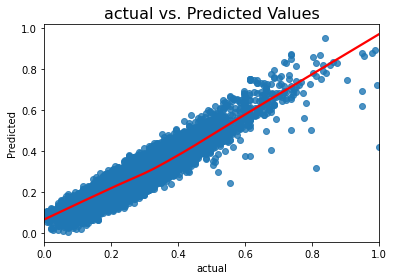

In [28]:
from sklearn import datasets
from sklearn.model_selection import cross_val_predict
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df1=pd.read_csv('/content/gdrive/My Drive/oc/oc_400_final_results.csv', sep=',',header=None)
df1=df1.drop([0,1,2],axis=1)
df1=df1.drop([0],axis=0)
df1.head()
print(df1.keys())
fig, ax = plt.subplots(1,1)
sns.regplot(x=list(map(float, df1[3])) , y=list(map(float, df1[4])) , lowess=True, ax=ax, line_kws={'color': 'red'})
ax.set_title('actual vs. Predicted Values', fontsize=16)
ax.set(ylabel='Predicted', xlabel='actual')

In [33]:
def mape(row):
    return abs(row.Forecast - row.Actual) / ((abs(row.Actual) + abs(row.Forecast))/2)

# create the pandas dataframe if you dont have one already
df=pd.DataFrame.from_dict({'Actual':list(map(float, df1[3])), 'Forecast':list(map(float, df1[4]))})

# apply the above function on each row 
smape = df.apply(mape, axis=1).sum() * (1/len(df))
print(smape)

0.19741081131236893


In [34]:
val_dict = dict()
val_dict['rmse']=[]
val_dict['r2']=[]
val_dict['manualr2']=[]
val_dict['smape']=[]
val_dict['mae']=[]
rmse_list =[]
r2_list =[]
mae_list =[]
smape_list =[]

rmse_list.append( sqrt(mean_squared_error(y_pred , y_test )))

r2_list.append(r2_score(y_pred , y_test ))
mae_list.append(mean_absolute_error(y_pred , y_test ))
# manualr2_list.append(manualr2(y_pred,y_test))
val_dict['rmse'].append(rmse_list)
val_dict['r2'].append(svr_rbf.score(X_test, y_pred))
val_dict['manualr2'].append(manualr2(y_pred,output))
val_dict['mae'].append(mae_list)
# val_dict['mae'].append(mae_list)
val_dict['smape'].append(smape)
log_df = pd.DataFrame(val_dict)
log_df.to_csv('/content/gdrive/My Drive/oc/oc_val_r.csv')
